240000


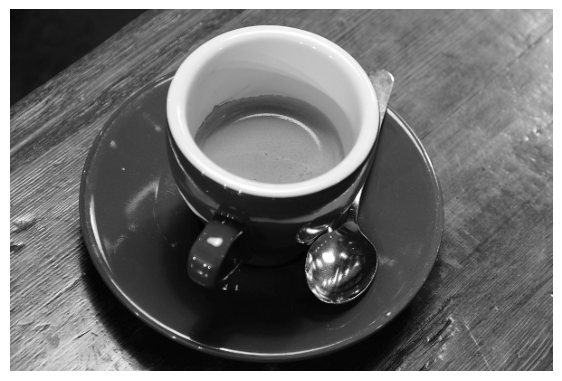

In [1]:
import skimage as si
import skimage.color as sc
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as ss
from algorithms import Algorithms
import time

img = sc.rgb2gray( si.data.coffee() )

print( np.prod( img.shape ) )

plt.figure( figsize = ( 7, 7 ) )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

In [2]:
N_kernel = 7
kernel = np.full( ( N_kernel, N_kernel ), 1 / ( N_kernel ** 2 ) )

def A( x ):
    return ss.convolve2d( x, kernel, mode = "same" )

def A_transpose( x ):
    return ss.correlate2d( x, kernel, mode = "same" )

def ATA( x ):
    return A_transpose( A( x ) )

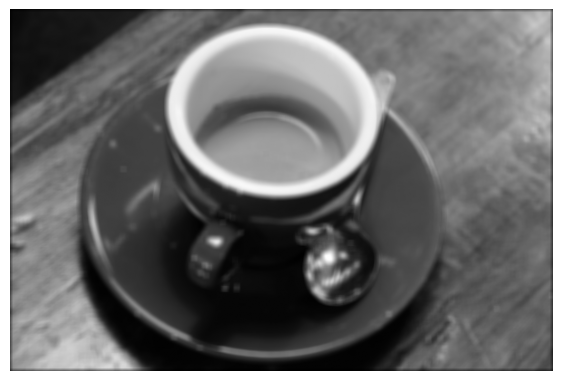

In [3]:
b = A( img )
plt.figure( figsize = ( 7, 7 ) )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

Note que: $f(x) = \frac{1}{2}||Ax - b||_2^2 = \frac{1}{2} x^T (A^TA) x -x^T(A^Tb) + \frac{1}{2}b^Tb$.

<!-- Note que nesse caso, um tamanho de passo que garante a convergência do algoritmo é $\lambda = 1 / L$, onde $L$ é a constante de Lipschitz, que nesse caso é dada por : $||A^T A||_2^2$ -->

No gradiente conjugado, a matriz $Q = A^TA$.



In [4]:
def f( x ):
    return 1/2 * ( (A( x ) - b) ** 2 ).sum()

def grad_f( x ):
    return A_transpose( A( x ) - b )

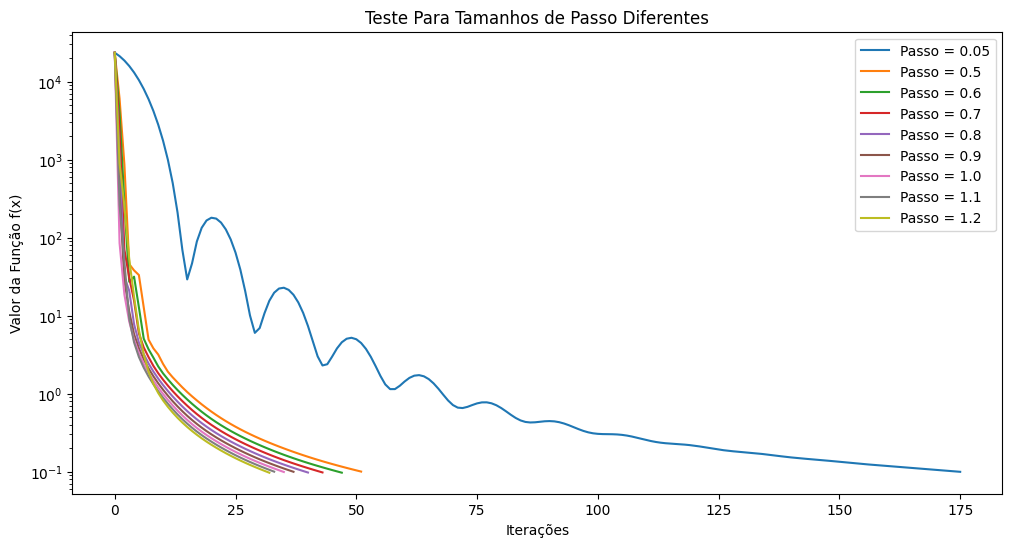

In [5]:
steps = [ 0.05, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2 ]
x = np.zeros_like( img )

lista = []
for step in steps:
    iters_nesterov_fixo = Algorithms.nesterov_fixo( f, grad_f, x = x, step = step, tol = 1.0e-1 )
    lista.append( iters_nesterov_fixo )

plt.figure( figsize = ( 12, 6 ) )
for i, step in zip( lista, steps ):
    f_vals_nesterov_fixo = [ f( x ) for x in i ]
    plt.semilogy( f_vals_nesterov_fixo, label = f'Passo = {step}' )
plt.title('Teste Para Tamanhos de Passo Diferentes')
plt.xlabel('Iterações')
plt.ylabel('Valor da Função f(x)')
plt.legend()
plt.show()


Vamos considerar o tamanho de passo $\lambda = 1.0$

In [6]:
x0 = np.zeros_like( img )
x = np.zeros_like( img )

iters_mdbe = Algorithms.mdbe( f, grad_f, Q = ATA, x0 = x0, tol = 1.0e-1 )

In [7]:
iters_mdpf = Algorithms.mdpf( f, grad_f, x0 = x0, step = 1, tol = 1.0e-1 )

In [8]:
iters_nesterov_fixo = Algorithms.nesterov_fixo( f, grad_f, x = x, step = 1, tol = 1.0e-1 )

In [9]:
iters_nesterov_exato = Algorithms.nesterov_exato( f, grad_f, Q = ATA, x = x, tol = 1.0e-1 )

In [10]:
iters_nesterov_backtracking = Algorithms.nesterov_backtracking( f, grad_f, x, step = 1.3, sigma = 1.0e-2, beta = 0.95, tol = 1.0e-1 )

In [11]:
iters_conjugate = Algorithms.conjugate( ATA, A_transpose( b ), x0, f, tol = 1.0e-1 )


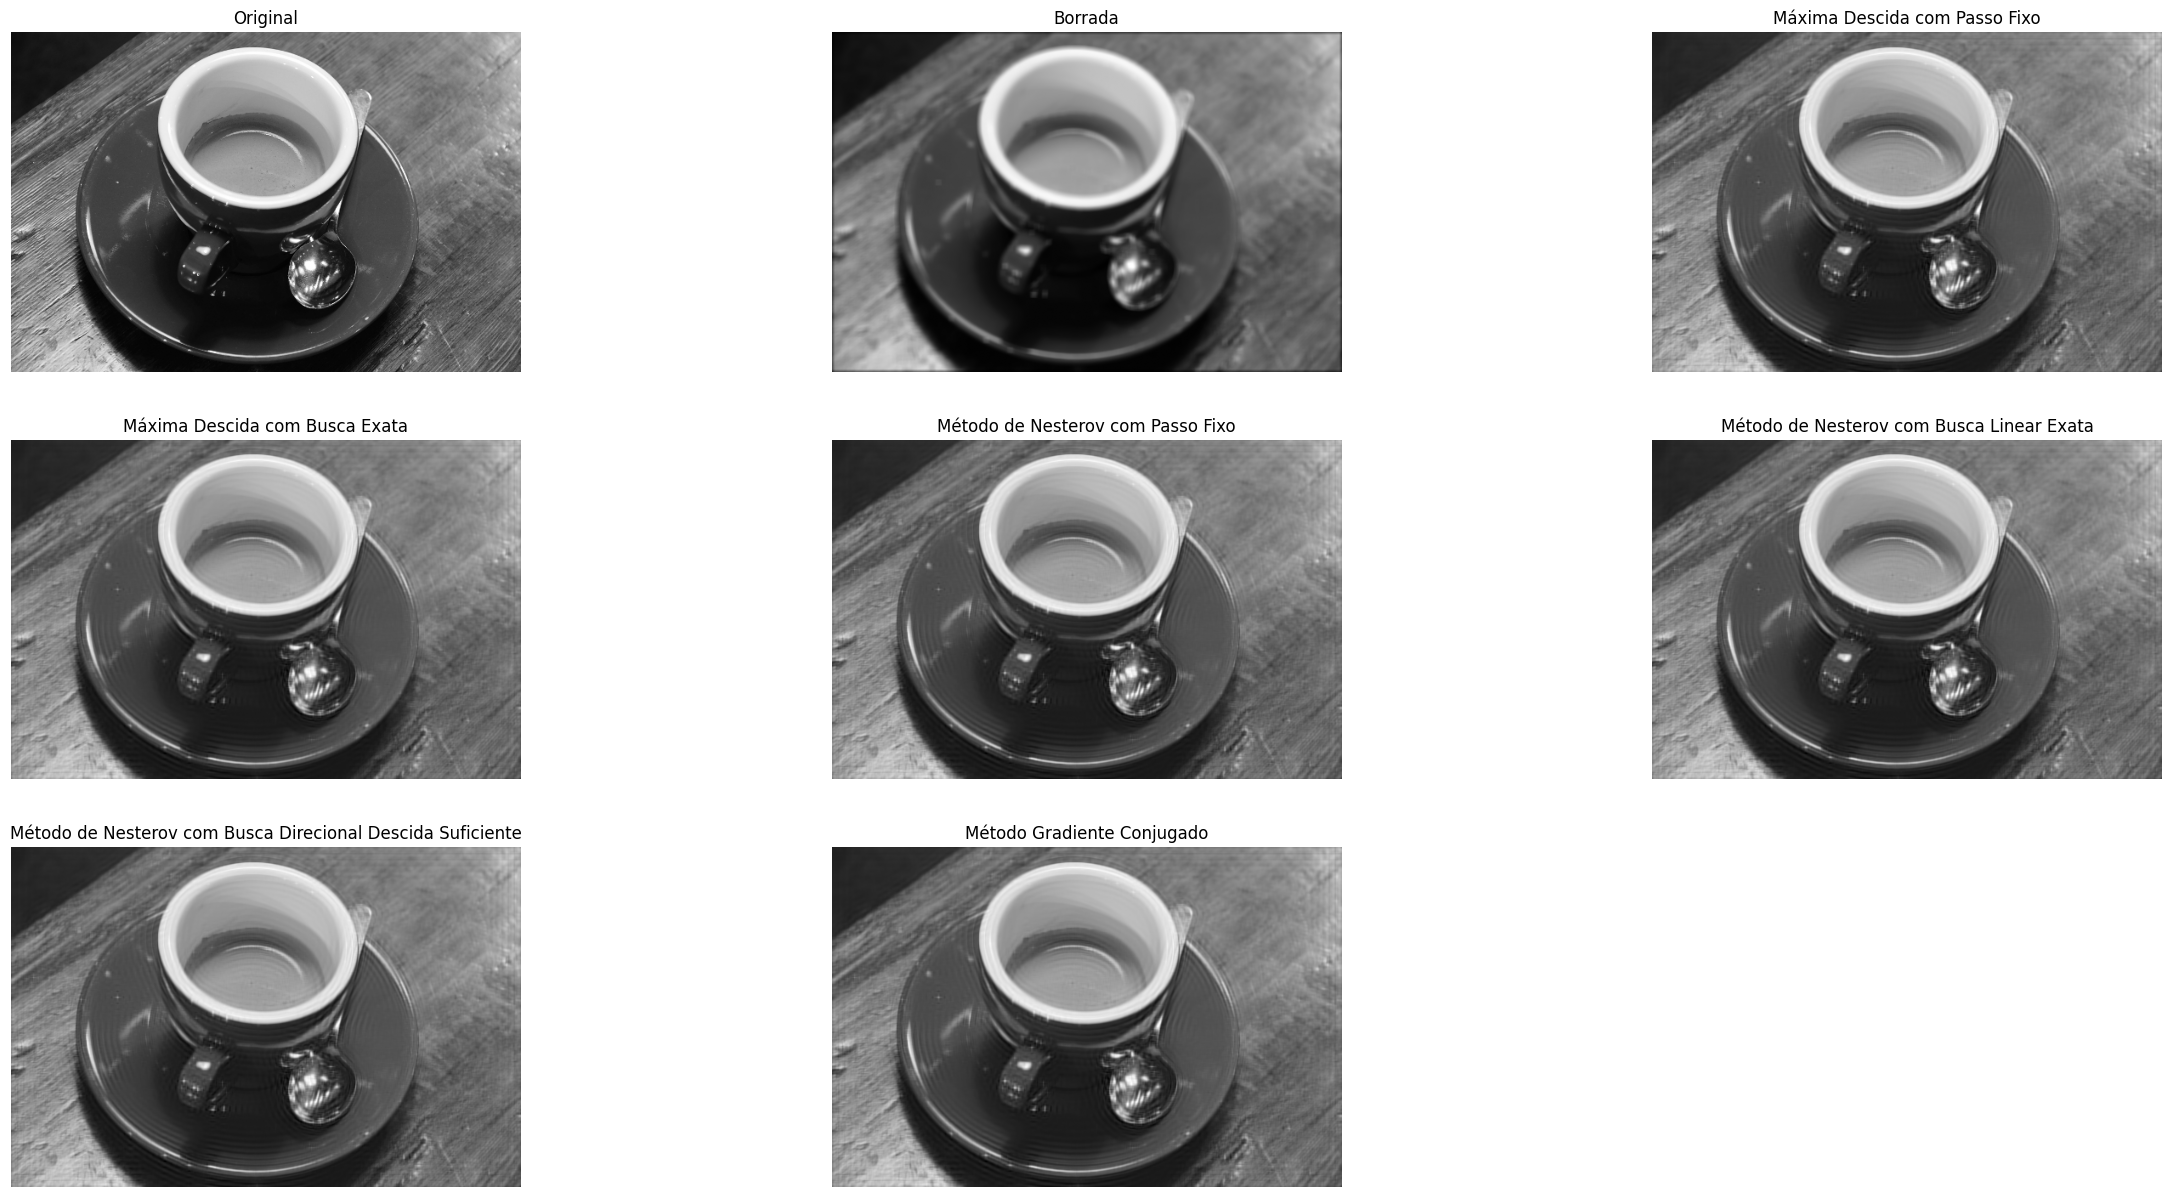

In [12]:
plt.figure( figsize = ( 30, 15 ) )

plt.subplot( 3, 3, 1 )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Original" )

plt.subplot( 3, 3, 2 )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Borrada" )

plt.subplot( 3, 3, 3 )
plt.imshow( iters_mdpf[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Máxima Descida com Passo Fixo" )

plt.subplot( 3, 3, 4 )
plt.imshow( iters_mdbe[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Máxima Descida com Busca Exata" )

plt.subplot( 3, 3, 5 )
plt.imshow( iters_nesterov_fixo[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Passo Fixo" )

plt.subplot( 3, 3, 6 )
plt.imshow( iters_nesterov_exato[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Busca Linear Exata" )

plt.subplot( 3, 3, 7 )
plt.imshow( iters_nesterov_backtracking[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Busca Direcional Descida Suficiente" )

plt.subplot( 3, 3, 8 )
plt.imshow( iters_conjugate[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método Gradiente Conjugado" )

plt.show()


In [13]:
print( f"O número de iterações do método da máxima descida com busca exata foi de: {len( iters_mdbe )}\n")
print( f"O número de iterações do método da máxima descida com passo fixo foi de: {len( iters_mdpf )}\n")
print( f"O número de iterações do método Nesterov com Passo Fixo foi de: {len( iters_nesterov_fixo )}\n")
print( f"O número de iterações do método Gradiente Conjugado foi de: {len( iters_conjugate )}\n")
print( f"O número de iterações do método Nesterov com Busca Linear Exata foi de: { len( iters_nesterov_exato ) }\n" )
print( f"O número de iterações do método Nesterov com Busca Direcional Descida Suficiente foi de: { len( iters_nesterov_backtracking ) }\n" )

O número de iterações do método da máxima descida com busca exata foi de: 105

O número de iterações do método da máxima descida com passo fixo foi de: 204

O número de iterações do método Nesterov com Passo Fixo foi de: 36

O número de iterações do método Gradiente Conjugado foi de: 18

O número de iterações do método Nesterov com Busca Linear Exata foi de: 31

O número de iterações do método Nesterov com Busca Direcional Descida Suficiente foi de: 33



In [14]:
f_vals_mdbe = [ f( x ) for x in iters_mdbe ]
f_vals_mdpf = [ f( x ) for x in iters_mdpf ]
f_vals_nesterov_fixo = [ f( x ) for x in iters_nesterov_fixo ]
f_vals_conjugate = [ f( x ) for x in iters_conjugate ]
f_vals_nesterov_exato = [ f( x ) for x in iters_nesterov_exato ]
f_vals_nesterov_backtracking = [ f( x ) for x in iters_nesterov_backtracking ]

(np.float64(-10.15),
 np.float64(213.15),
 np.float64(0.0531000777659723),
 np.float64(43655.16111362628))

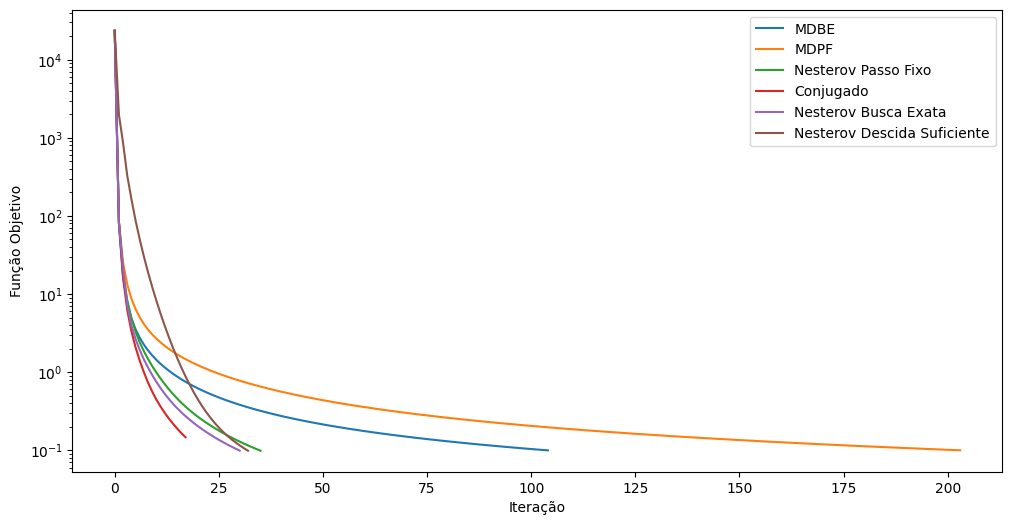

In [15]:
plt.figure( figsize = ( 12, 6 ) )
plt.semilogy( f_vals_mdbe )
plt.semilogy( f_vals_mdpf )
plt.semilogy( f_vals_nesterov_fixo )
plt.semilogy( f_vals_conjugate )
plt.semilogy( f_vals_nesterov_exato )
plt.semilogy( f_vals_nesterov_backtracking )
plt.legend( [ "MDBE", "MDPF", "Nesterov Passo Fixo", "Conjugado", "Nesterov Busca Exata", "Nesterov Descida Suficiente" ] )
plt.xlabel( "Iteração" )
plt.ylabel( "Função Objetivo" )
plt.axis( "tight" )

In [16]:
def compare_methods( methods, f, grad_f, x0, tol = 1e-4, max_iter = 10000 ):
    results = {}
    for name, method in methods.items():
        print( f"Executando método: {name}" )
        start_time = time.perf_counter()
        iters = method( f, grad_f, x0, tol = tol, max_iter = max_iter )
        end_time = time.perf_counter()

        exec_time = end_time - start_time
        values = [ f( x ) for x in iters ]

        results[ name ] = {
            "iterations": len( iters ),
            "execution_time": exec_time,
            "function_values": values,
            "iters" : iters
        }
        print( f"{name}: {len( iters )} iterações, {exec_time:.4f} segundos." )
    return results

In [17]:
x0 = np.zeros_like( img )
tol = 1e-2
max_iter = 999


In [18]:
methods = {
    "MDBE": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdbe( f, grad_f, Q = ATA, x0 = x0, tol = tol, max_iter = max_iter ),
    "MDPF": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdpf( f, grad_f, x0 = x0, tol = tol, step = 1, max_iter = max_iter ),
    "Nesterov Passo Fixo": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_fixo( f, grad_f, x0, step = 1, tol = tol, max_iter = max_iter ),
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato( f, grad_f, x = x0, Q = ATA, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( ATA, A_transpose( b ), x0, f, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 1.2, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Executando método: MDBE
MDBE: 849 iterações, 219.3431 segundos.
Executando método: MDPF
MDPF: 1000 iterações, 155.9961 segundos.
Executando método: Nesterov Passo Fixo
Nesterov Passo Fixo: 108 iterações, 16.6594 segundos.
Executando método: Nesterov Busca Exata
Nesterov Busca Exata: 93 iterações, 24.3529 segundos.
Executando método: Gradiente Conjugado
Gradiente Conjugado: 59 iterações, 19.7681 segundos.
Executando método: Nesterov Backtracking
Nesterov Backtracking: 98 iterações, 25.7517 segundos.


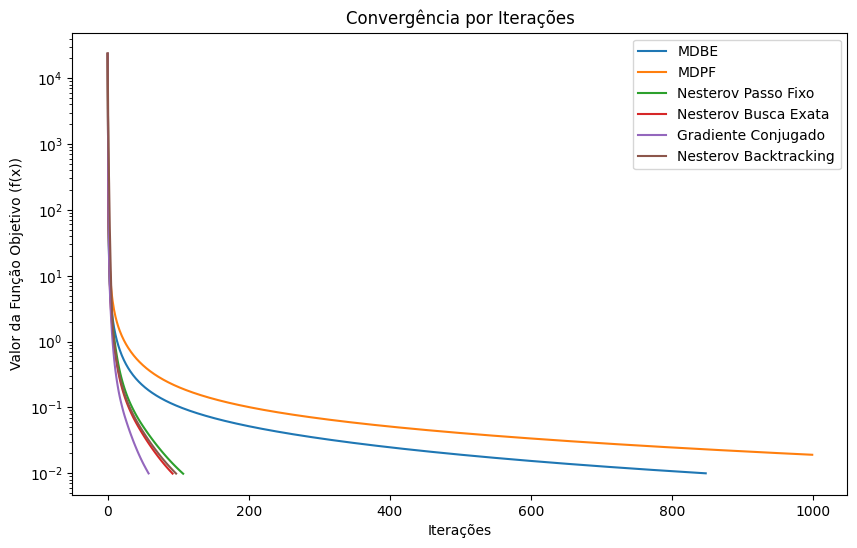

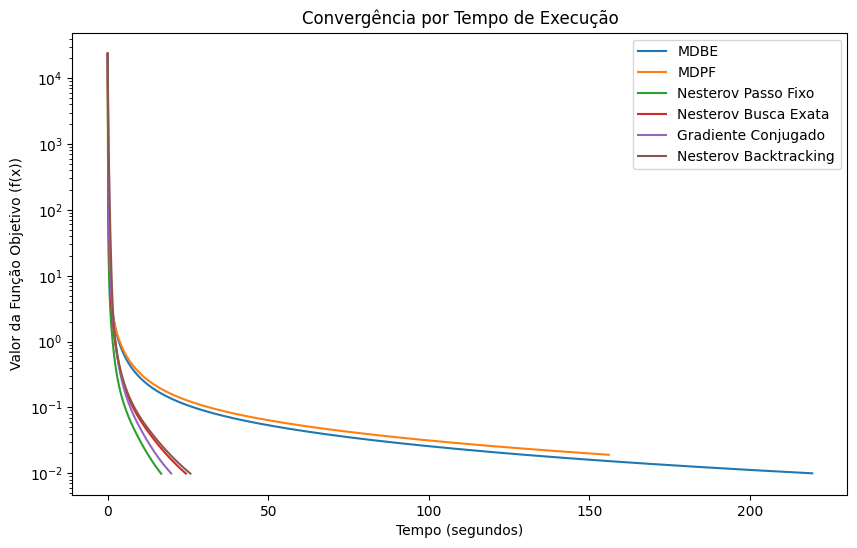

In [19]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = np.linspace( 0, res[ "execution_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


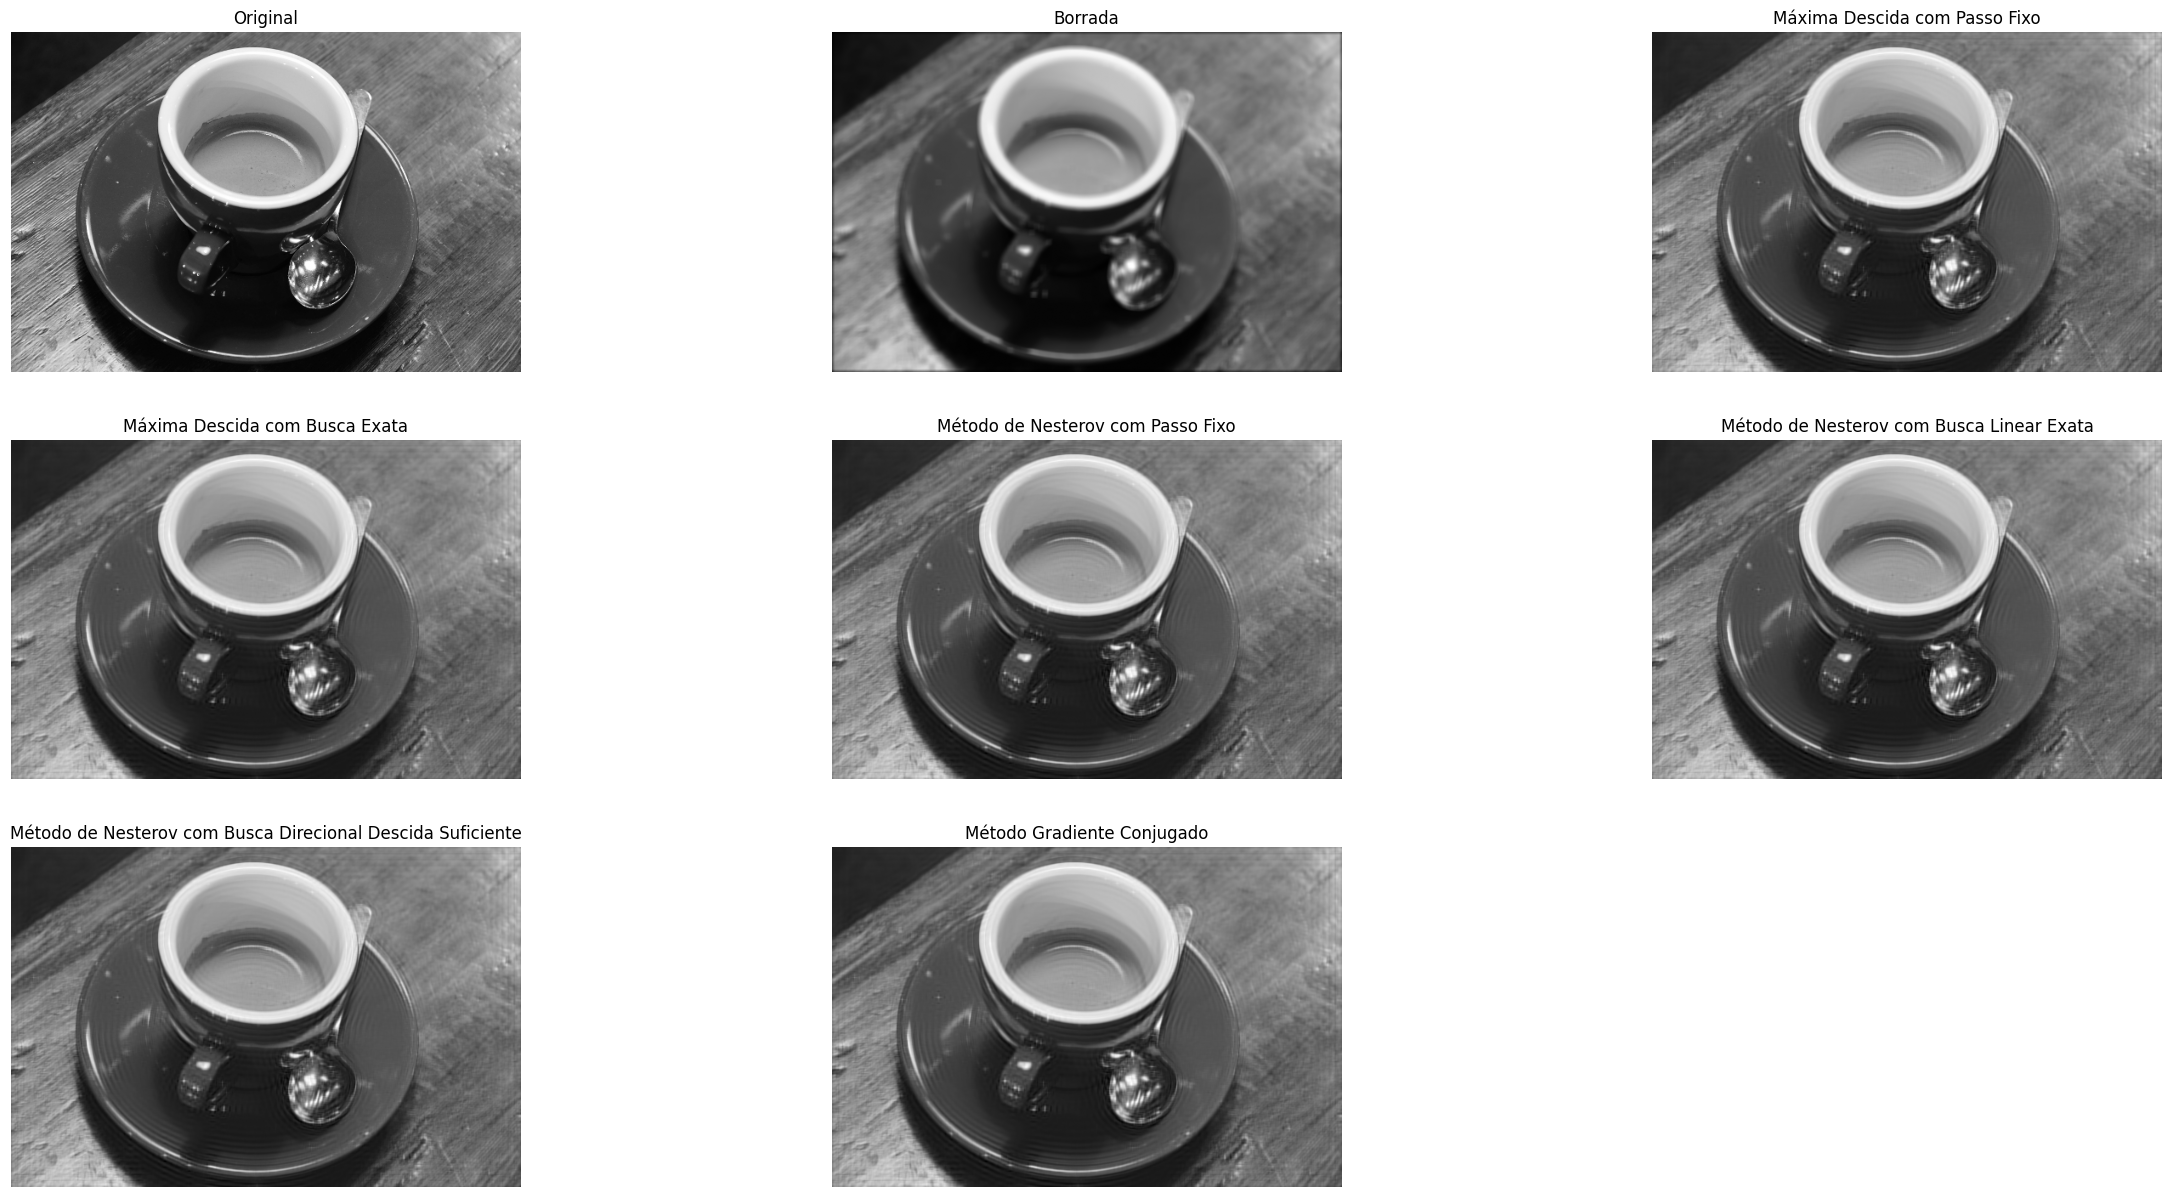

In [20]:
plt.figure( figsize = ( 30, 15 ) )

plt.subplot( 3, 3, 1 )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Original" )

plt.subplot( 3, 3, 2 )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Borrada" )

plt.subplot( 3, 3, 3 )
plt.imshow( iters_mdpf[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Máxima Descida com Passo Fixo" )

plt.subplot( 3, 3, 4 )
plt.imshow( iters_mdbe[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Máxima Descida com Busca Exata" )

plt.subplot( 3, 3, 5 )
plt.imshow( iters_nesterov_fixo[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Passo Fixo" )

plt.subplot( 3, 3, 6 )
plt.imshow( iters_nesterov_exato[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Busca Linear Exata" )

plt.subplot( 3, 3, 7 )
plt.imshow( iters_nesterov_backtracking[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Busca Direcional Descida Suficiente" )

plt.subplot( 3, 3, 8 )
plt.imshow( iters_conjugate[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método Gradiente Conjugado" )

plt.show()


In [21]:
for metodo, valores in results.items():
  ultimo_valor = valores['function_values'][-1]
  print( f'Método: {metodo} levou a uma avaliação de f(x) igual a {ultimo_valor}' )

Método: MDBE levou a uma avaliação de f(x) igual a 0.009995410125104904
Método: MDPF levou a uma avaliação de f(x) igual a 0.019117253103951643
Método: Nesterov Passo Fixo levou a uma avaliação de f(x) igual a 0.009853020919097797
Método: Nesterov Busca Exata levou a uma avaliação de f(x) igual a 0.00989388402381354
Método: Gradiente Conjugado levou a uma avaliação de f(x) igual a 0.009959639336267286
Método: Nesterov Backtracking levou a uma avaliação de f(x) igual a 0.009903947214630943


# Comparando algoritmos por número de iteração


In [22]:
x0 = np.zeros_like( img )
tol = 1e-5
max_iter = 200


In [23]:
methods = {
    "MDBE": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdbe( f, grad_f, Q = ATA, x0 = x0, tol = tol, max_iter = max_iter ),
    "MDPF": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdpf( f, grad_f, x0 = x0, tol = tol, step = 1, max_iter = max_iter ),
    "Nesterov Passo Fixo": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_fixo( f, grad_f, x0, step = 1, tol = tol, max_iter = max_iter ),
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato( f, grad_f, x = x0, Q = ATA, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( ATA, A_transpose( b ), x0, f, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 1.2, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Executando método: MDBE
MDBE: 201 iterações, 55.1090 segundos.
Executando método: MDPF
MDPF: 201 iterações, 31.0312 segundos.
Executando método: Nesterov Passo Fixo
Nesterov Passo Fixo: 201 iterações, 31.0427 segundos.
Executando método: Nesterov Busca Exata
Nesterov Busca Exata: 201 iterações, 52.3632 segundos.
Executando método: Gradiente Conjugado
Gradiente Conjugado: 201 iterações, 64.7914 segundos.
Executando método: Nesterov Backtracking
Nesterov Backtracking: 201 iterações, 51.9665 segundos.


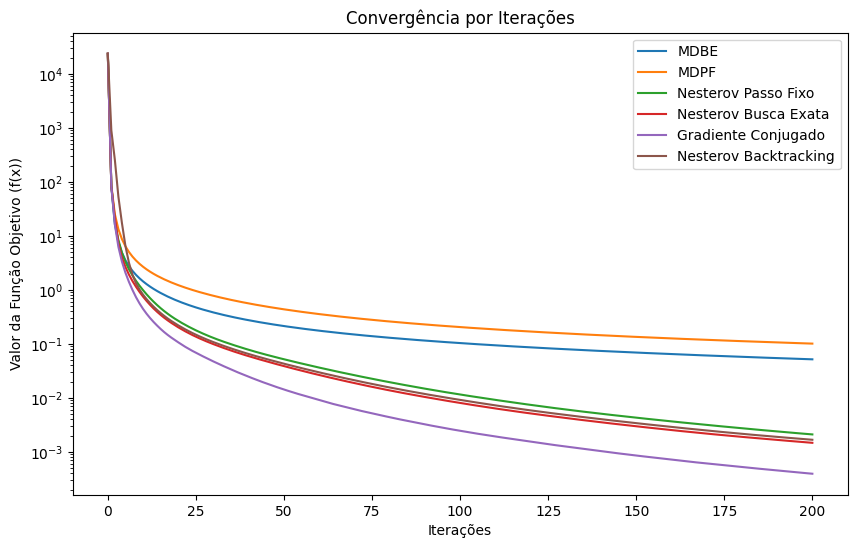

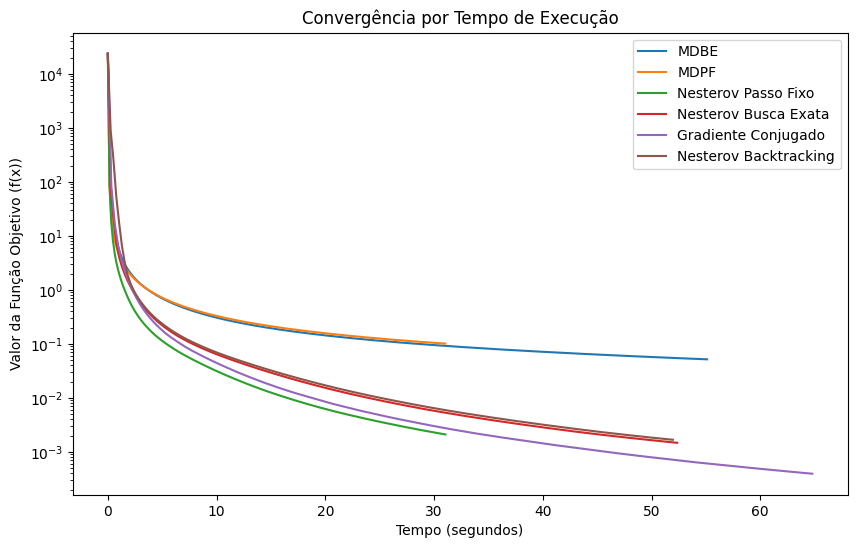

In [24]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = np.linspace( 0, res[ "execution_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


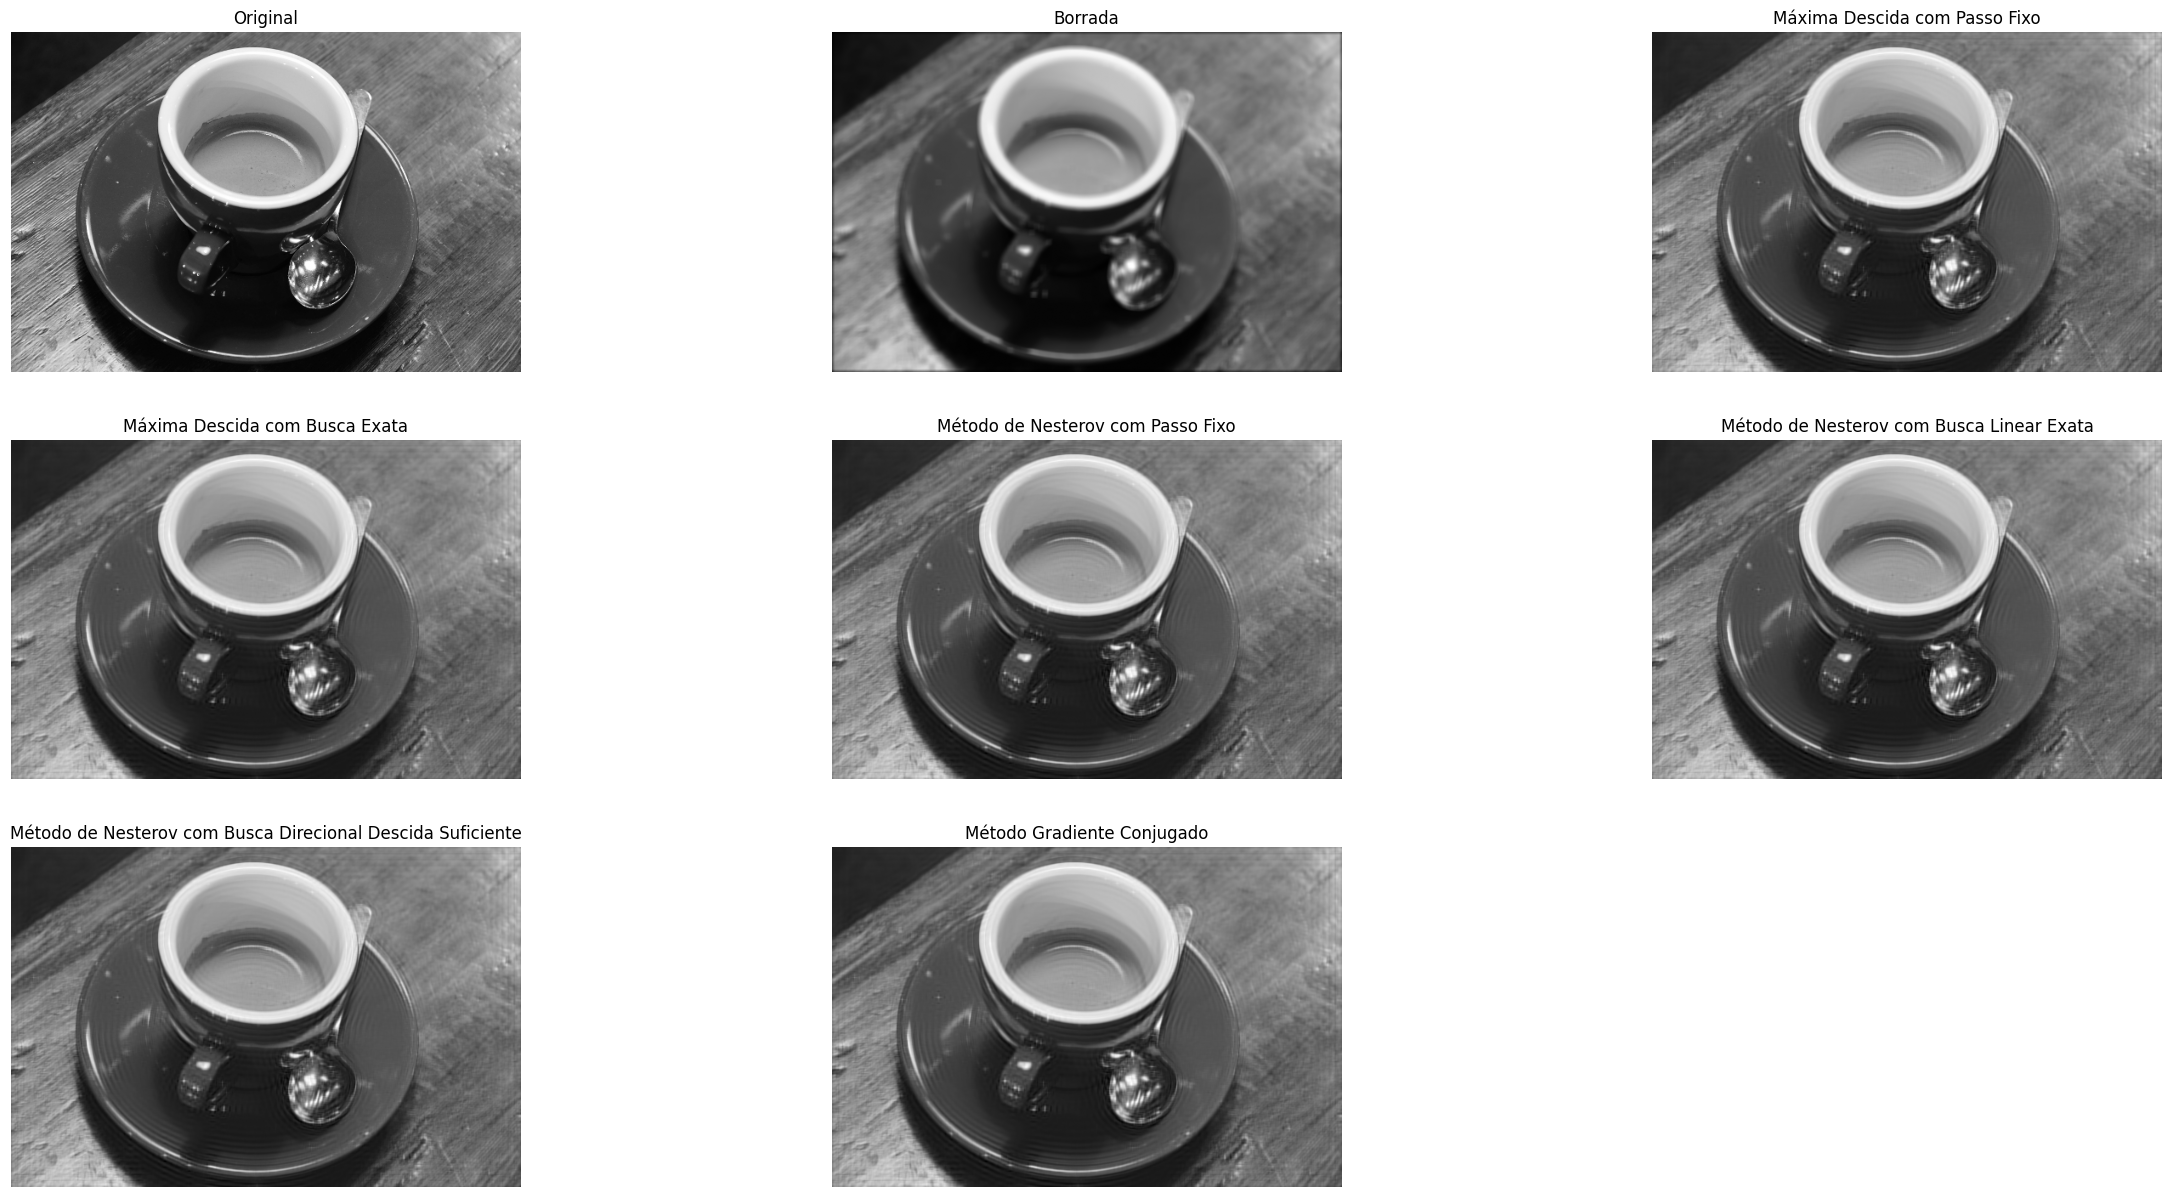

In [25]:
plt.figure( figsize = ( 30, 15 ) )

plt.subplot( 3, 3, 1 )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Original" )

plt.subplot( 3, 3, 2 )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Borrada" )

plt.subplot( 3, 3, 3 )
plt.imshow( iters_mdpf[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Máxima Descida com Passo Fixo" )

plt.subplot( 3, 3, 4 )
plt.imshow( iters_mdbe[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Máxima Descida com Busca Exata" )

plt.subplot( 3, 3, 5 )
plt.imshow( iters_nesterov_fixo[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Passo Fixo" )

plt.subplot( 3, 3, 6 )
plt.imshow( iters_nesterov_exato[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Busca Linear Exata" )

plt.subplot( 3, 3, 7 )
plt.imshow( iters_nesterov_backtracking[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método de Nesterov com Busca Direcional Descida Suficiente" )

plt.subplot( 3, 3, 8 )
plt.imshow( iters_conjugate[ -1 ], cmap = plt.cm.gray )
plt.axis( "off" )
plt.title( "Método Gradiente Conjugado" )

plt.show()


In [26]:
for metodo, valores in results.items():
  ultimo_valor = valores['function_values'][-1]
  print( f'Método: {metodo} levou a uma avaliação de f(x) igual a {ultimo_valor}' )

Método: MDBE levou a uma avaliação de f(x) igual a 0.05188346844186539
Método: MDPF levou a uma avaliação de f(x) igual a 0.10135005383005909
Método: Nesterov Passo Fixo levou a uma avaliação de f(x) igual a 0.002113904038370692
Método: Nesterov Busca Exata levou a uma avaliação de f(x) igual a 0.001477756539106449
Método: Gradiente Conjugado levou a uma avaliação de f(x) igual a 0.00039592956103905045
Método: Nesterov Backtracking levou a uma avaliação de f(x) igual a 0.0016828223816437663
